In [1]:
import os
import pickle
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import joblib
import tensorflow as tf

from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupShuffleSplit

from sklearn.metrics import (

    accuracy_score,
    precision_score,
    recall_score,
    f1_score,

    roc_auc_score,
    roc_curve,

    precision_recall_curve,
    average_precision_score,

    brier_score_loss,

    confusion_matrix,
    ConfusionMatrixDisplay


)
from sklearn.calibration import calibration_curve

warnings.filterwarnings("ignore")

plt.style.use("ggplot")

SEED = 42

np.random.seed(SEED)

tf.random.set_seed(SEED)

2026-06-30 06:32:13.469341: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782801133.692461      15 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782801133.757486      15 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782801134.290661      15 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782801134.290712      15 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782801134.290715      15 computation_placer.cc:177] computation placer alr

In [2]:
# ==========================================================
# Locked Asset Locations
# ==========================================================

CLINICAL_PATH = "/kaggle/input/datasets/chandan294/clinical-assets"

ECG_PATH = "/kaggle/input/notebooks/chandan294/08b-final-training"

FUSION_PATH = "/kaggle/input/notebooks/chandan294/09-confidence-adaptive-fusion"

print("Clinical Path :", CLINICAL_PATH)
print("ECG Path      :", ECG_PATH)
print("Fusion Path   :", FUSION_PATH)

Clinical Path : /kaggle/input/datasets/chandan294/clinical-assets
ECG Path      : /kaggle/input/notebooks/chandan294/08b-final-training
Fusion Path   : /kaggle/input/notebooks/chandan294/09-confidence-adaptive-fusion


In [3]:
# ==========================================================
# Verify Assets
# ==========================================================

required_clinical = [

    "05_random_forest.pkl",
    "04_selected_features.csv",

    "X_train_binary.csv",
    "X_test_binary.csv",

    "y_train_binary.csv",
    "y_test_binary.csv"

]

required_ecg = [

    "cache/X_full.npy",
    "cache/y_full.npy",
    "cache/patient_ids.npy",

    "results/models/08b_best_cnn.keras"

]

required_fusion = [

    "09_confidence_adaptive_fusion.pkl",
    "09_case_studies.csv"

]

print("="*60)
print("Clinical Assets")
print("="*60)

for f in required_clinical:

    exists = os.path.exists(

        os.path.join(

            CLINICAL_PATH,

            f

        )

    )

    print(f"{f:<40} {exists}")

print()

print("="*60)
print("ECG Assets")
print("="*60)

for f in required_ecg:

    exists = os.path.exists(

        os.path.join(

            ECG_PATH,

            f

        )

    )

    print(f"{f:<40} {exists}")

print()

print("="*60)
print("Fusion Assets")
print("="*60)

for f in required_fusion:

    exists = os.path.exists(

        os.path.join(

            FUSION_PATH,

            f

        )

    )

    print(f"{f:<40} {exists}")

Clinical Assets
05_random_forest.pkl                     True
04_selected_features.csv                 True
X_train_binary.csv                       True
X_test_binary.csv                        True
y_train_binary.csv                       True
y_test_binary.csv                        True

ECG Assets
cache/X_full.npy                         True
cache/y_full.npy                         True
cache/patient_ids.npy                    True
results/models/08b_best_cnn.keras        True

Fusion Assets
09_confidence_adaptive_fusion.pkl        True
09_case_studies.csv                      True


In [4]:
# ==========================================================
# Runtime Summary
# ==========================================================

gpu_devices = tf.config.list_physical_devices("GPU")

summary = pd.DataFrame({

    "Property":[

        "TensorFlow Version",

        "NumPy Version",

        "Pandas Version",

        "GPU Available",

        "GPU Count",

        "Random Seed"

    ],

    "Value":[

        tf.__version__,

        np.__version__,

        pd.__version__,

        len(gpu_devices)>0,

        len(gpu_devices),

        SEED

    ]

})

summary

2026-06-30 06:32:28.429611: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


,Property,Value
0,TensorFlow Version,2.19.0
1,NumPy Version,2.4.6
2,Pandas Version,2.3.3
3,GPU Available,False
4,GPU Count,0
5,Random Seed,42


In [5]:
print("="*70)

print("Notebook 11")
print("Comprehensive Evaluation & Ablation Study")

print("="*70)

print()

print("Clinical Model  : Random Forest")

print("ECG Model       : 1D CNN")

print("Fusion          : Confidence-Adaptive")

print("Explainability  : SHAP + Integrated Gradients")

print()

print("No training will be performed.")

print("Only evaluation of locked models.")

print("="*70)

Notebook 11
Comprehensive Evaluation & Ablation Study

Clinical Model  : Random Forest
ECG Model       : 1D CNN
Fusion          : Confidence-Adaptive
Explainability  : SHAP + Integrated Gradients

No training will be performed.
Only evaluation of locked models.


# Section B — Reload Locked Clinical Branch

This section reloads the finalized clinical branch developed in previous notebooks.

The following assets are loaded:

- Locked Random Forest model (Notebook 05)
- Consensus-selected feature list (Notebook 04)
- Leakage-free train/test split (Notebook 02)
- Probability calibration (Notebook 09)

The calibrated model is then used to generate probability estimates on the held-out clinical test set.

These probabilities will be reused throughout the remainder of the notebook for calibration analysis, ROC curves, confidence intervals, and quantitative evaluation.

In [6]:
# ==========================================================
# Load Clinical Assets
# ==========================================================

rf_model = joblib.load(
    os.path.join(
        CLINICAL_PATH,
        "05_random_forest.pkl"
    )
)

selected_df = pd.read_csv(
    os.path.join(
        CLINICAL_PATH,
        "04_selected_features.csv"
    )
)

clinical_features = selected_df["Feature"].tolist()

X_train_full = pd.read_csv(
    os.path.join(
        CLINICAL_PATH,
        "X_train_binary.csv"
    )
)

X_test_full = pd.read_csv(
    os.path.join(
        CLINICAL_PATH,
        "X_test_binary.csv"
    )
)

y_train_clinical = pd.read_csv(
    os.path.join(
        CLINICAL_PATH,
        "y_train_binary.csv"
    )
).squeeze()

y_test_clinical = pd.read_csv(
    os.path.join(
        CLINICAL_PATH,
        "y_test_binary.csv"
    )
).squeeze()

X_train_clinical = X_train_full[
    clinical_features
].copy()

X_test_clinical = X_test_full[
    clinical_features
].copy()

print("="*60)
print("Clinical Branch Loaded")
print("="*60)

print("Training Shape :", X_train_clinical.shape)
print("Testing Shape  :", X_test_clinical.shape)

print()

print("Selected Features :", len(clinical_features))

print()

display(selected_df)

Clinical Branch Loaded
Training Shape : (736, 11)
Testing Shape  : (184, 11)

Selected Features : 11



,Feature
0,cp
1,exang
2,ca
3,sex
4,chol_missing
5,slope_missing
6,thal
7,thalach
8,age
9,oldpeak


In [7]:
# ==========================================================
# Rebuild Calibrated Random Forest
# ==========================================================

rf_params = rf_model.get_params()

rf_for_calibration = RandomForestClassifier(
    **rf_params
)

calibrated_clinical = CalibratedClassifierCV(

    estimator=rf_for_calibration,

    method="sigmoid",

    cv=5

)

calibrated_clinical.fit(

    X_train_clinical,

    y_train_clinical

)

print("="*60)
print("Clinical Calibration Completed")
print("="*60)

print()

print("Calibration Method : Platt Scaling")

print("Cross Validation   : 5-fold")

print("Probability Output : Calibrated")

Clinical Calibration Completed

Calibration Method : Platt Scaling
Cross Validation   : 5-fold
Probability Output : Calibrated


In [8]:
# ==========================================================
# Clinical Predictions
# ==========================================================

clinical_test_probs = calibrated_clinical.predict_proba(
    X_test_clinical
)[:,1]

clinical_test_preds = (
    clinical_test_probs >= 0.50
).astype(int)

print("="*60)

print("Prediction Summary")

print("="*60)

print()

print("Probability Range")

print(

    clinical_test_probs.min(),

    "→",

    clinical_test_probs.max()

)

print()

print("Positive Predictions :", clinical_test_preds.sum())

print("Negative Predictions :", len(clinical_test_preds)-clinical_test_preds.sum())

Prediction Summary

Probability Range
0.06994540387405505 → 0.9322210945560799

Positive Predictions : 110
Negative Predictions : 74


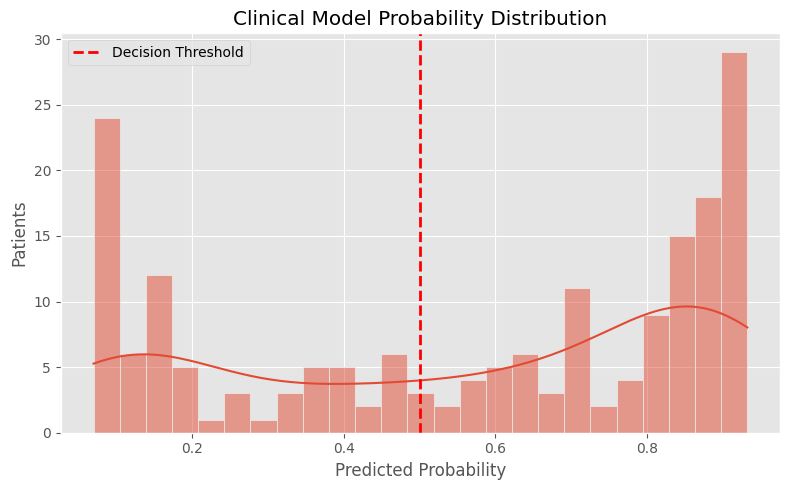

In [9]:
# ==========================================================
# Clinical Probability Distribution
# ==========================================================

plt.figure(figsize=(8,5))

sns.histplot(

    clinical_test_probs,

    bins=25,

    kde=True

)

plt.axvline(

    0.5,

    linestyle="--",

    linewidth=2,

    color="red",

    label="Decision Threshold"

)

plt.xlabel("Predicted Probability")

plt.ylabel("Patients")

plt.title("Clinical Model Probability Distribution")

plt.legend()

plt.tight_layout()

plt.show()

In [10]:
# ==========================================================
# Clinical Summary
# ==========================================================

clinical_summary = pd.DataFrame({

    "Property":[

        "Training Samples",

        "Testing Samples",

        "Selected Features",

        "Classifier",

        "Calibration",

        "Decision Threshold"

    ],

    "Value":[

        len(X_train_clinical),

        len(X_test_clinical),

        len(clinical_features),

        "Random Forest",

        "Platt Scaling",

        0.50

    ]

})

display(clinical_summary)

,Property,Value
0,Training Samples,736
1,Testing Samples,184
2,Selected Features,11
3,Classifier,Random Forest
4,Calibration,Platt Scaling
5,Decision Threshold,0.5


# Section C — Reload Locked ECG Branch

This section reloads the finalized ECG branch developed in Notebook 08b.

The following assets are restored:

- Locked CNN model
- Cached ECG signals
- Patient identifiers
- Patient-grouped train/validation/test split
- Probability calibration (Platt Scaling)

The exact GroupShuffleSplit configuration (random_state=42) is reused to regenerate the identical validation and test cohorts used during model development.

No retraining is performed.
Only inference and calibration are reproduced.

In [11]:
# ==========================================================
# Load Locked ECG Assets
# ==========================================================

cnn_model = tf.keras.models.load_model(
    os.path.join(
        ECG_PATH,
        "results",
        "models",
        "08b_best_cnn.keras"
    )
)

X_full = np.load(
    os.path.join(
        ECG_PATH,
        "cache",
        "X_full.npy"
    )
)

y_full = np.load(
    os.path.join(
        ECG_PATH,
        "cache",
        "y_full.npy"
    )
)

patient_ids = np.load(
    os.path.join(
        ECG_PATH,
        "cache",
        "patient_ids.npy"
    )
)

print("="*60)
print("ECG Assets Loaded")
print("="*60)

print("Signals Shape :", X_full.shape)
print("Labels Shape  :", y_full.shape)
print("Patients      :", patient_ids.shape[0])

print("\nUnique Patients :", len(np.unique(patient_ids)))

print("\nClass Distribution")
print(pd.Series(y_full).value_counts())

ECG Assets Loaded
Signals Shape : (21430, 1000, 12)
Labels Shape  : (21430,)
Patients      : 21430

Unique Patients : 18637

Class Distribution
1    12347
0     9083
Name: count, dtype: int64


In [12]:
# ==========================================================
# Regenerate Locked Patient Split
# ==========================================================

gss = GroupShuffleSplit(
    n_splits=1,
    train_size=0.70,
    random_state=SEED
)

train_idx, temp_idx = next(
    gss.split(
        X_full,
        y_full,
        groups=patient_ids
    )
)

X_temp = X_full[temp_idx]
y_temp = y_full[temp_idx]
patients_temp = patient_ids[temp_idx]

gss2 = GroupShuffleSplit(
    n_splits=1,
    train_size=0.50,
    random_state=SEED
)

val_idx, test_idx = next(
    gss2.split(
        X_temp,
        y_temp,
        groups=patients_temp
    )
)

X_val = X_temp[val_idx]
y_val = y_temp[val_idx]

X_test_ecg = X_temp[test_idx]
y_test_ecg = y_temp[test_idx]

print("="*60)
print("Patient-Level Split Recreated")
print("="*60)

split_df = pd.DataFrame({

    "Split":[
        "Validation",
        "Test"
    ],

    "ECGs":[
        len(X_val),
        len(X_test_ecg)
    ],

    "Positive Cases":[
        int(y_val.sum()),
        int(y_test_ecg.sum())
    ],

    "Negative Cases":[
        int(len(y_val)-y_val.sum()),
        int(len(y_test_ecg)-y_test_ecg.sum())
    ]

})

display(split_df)

Patient-Level Split Recreated


,Split,ECGs,Positive Cases,Negative Cases
0,Validation,3254,1892,1362
1,Test,3207,1842,1365


In [13]:
# ==========================================================
# Platt Scaling
# ==========================================================

raw_val_probs = cnn_model.predict(
    X_val,
    verbose=0
).ravel()

platt_ecg = LogisticRegression()

platt_ecg.fit(
    raw_val_probs.reshape(-1,1),
    y_val
)

print("="*60)
print("ECG Calibration Completed")
print("="*60)

print("Calibration Method : Platt Scaling")

I0000 00:00:1782801160.479243      53 service.cc:152] XLA service 0x79926800abe0 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782801160.479312      53 service.cc:160]   StreamExecutor device (0): Host, Default Version
I0000 00:00:1782801161.051756      53 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


ECG Calibration Completed
Calibration Method : Platt Scaling


In [14]:
# ==========================================================
# ECG Predictions
# ==========================================================

raw_test_probs = cnn_model.predict(
    X_test_ecg,
    verbose=0
).ravel()

ecg_test_probs = platt_ecg.predict_proba(
    raw_test_probs.reshape(-1,1)
)[:,1]

ecg_test_preds = (
    ecg_test_probs >= 0.50
).astype(int)

print("="*60)
print("Prediction Summary")
print("="*60)

print()

print("Probability Range")

print(
    ecg_test_probs.min(),
    "→",
    ecg_test_probs.max()
)

print()

print("Positive Predictions :", ecg_test_preds.sum())

print("Negative Predictions :", len(ecg_test_preds)-ecg_test_preds.sum())

Prediction Summary

Probability Range
0.07527830095426137 → 0.962187086578576

Positive Predictions : 1792
Negative Predictions : 1415


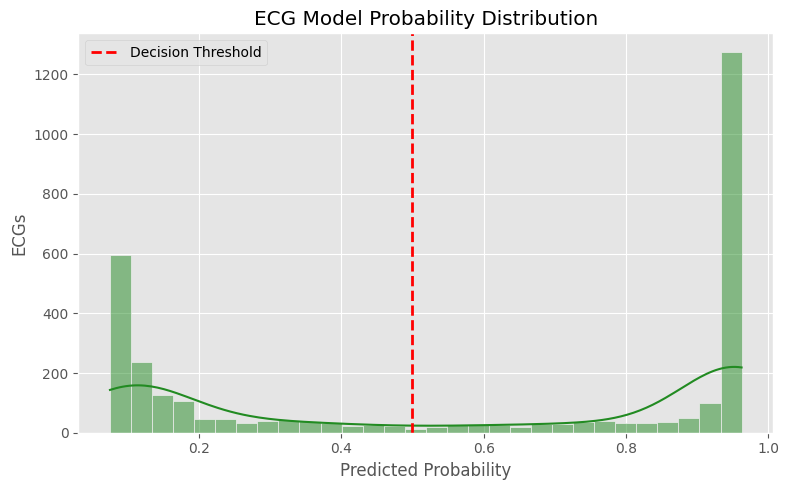

In [15]:
# ==========================================================
# ECG Probability Distribution
# ==========================================================

plt.figure(figsize=(8,5))

sns.histplot(
    ecg_test_probs,
    bins=30,
    kde=True,
    color="forestgreen"
)

plt.axvline(
    0.50,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Decision Threshold"
)

plt.xlabel("Predicted Probability")

plt.ylabel("ECGs")

plt.title("ECG Model Probability Distribution")

plt.legend()

plt.tight_layout()

plt.show()

In [16]:
# ==========================================================
# ECG Summary
# ==========================================================

ecg_summary = pd.DataFrame({

    "Property":[
        "Total ECGs",
        "Validation ECGs",
        "Test ECGs",
        "Unique Patients",
        "Architecture",
        "Calibration",
        "Decision Threshold"
    ],

    "Value":[
        len(X_full),
        len(X_val),
        len(X_test_ecg),
        len(np.unique(patient_ids)),
        "1D CNN (3 Conv Blocks)",
        "Platt Scaling",
        0.50
    ]

})

display(ecg_summary)

,Property,Value
0,Total ECGs,21430
1,Validation ECGs,3254
2,Test ECGs,3207
3,Unique Patients,18637
4,Architecture,1D CNN (3 Conv Blocks)
5,Calibration,Platt Scaling
6,Decision Threshold,0.5


# Section D — Bootstrap Confidence Intervals

Point estimates such as Accuracy, F1 Score, and AUC summarize model
performance on a single test set but provide no indication of statistical
uncertainty.

To quantify the robustness of the reported performance, bootstrap
resampling is performed independently for the Clinical and ECG branches.

For each metric:

- 1000 bootstrap samples are generated
- Sampling is performed with replacement
- 95% confidence intervals are computed using the percentile method

These confidence intervals provide a statistically grounded estimate of
performance variability and improve the reproducibility of the reported
results.

In [17]:
# ==========================================================
# Bootstrap Confidence Intervals
# ==========================================================

def bootstrap_metric_ci(
    y_true,
    y_probs,
    metric_fn,
    n_bootstrap=1000,
    threshold=0.50,
    seed=SEED
):

    rng = np.random.RandomState(seed)

    y_true = np.asarray(y_true)
    y_probs = np.asarray(y_probs)

    n = len(y_true)

    scores = []

    for _ in range(n_bootstrap):

        idx = rng.randint(0, n, n)

        yt = y_true[idx]
        yp = y_probs[idx]

        # Skip invalid samples
        if len(np.unique(yt)) < 2:
            continue

        if metric_fn == roc_auc_score:

            score = metric_fn(
                yt,
                yp
            )

        elif metric_fn == average_precision_score:

            score = metric_fn(
                yt,
                yp
            )

        elif metric_fn == brier_score_loss:

            score = metric_fn(
                yt,
                yp
            )

        else:

            pred = (yp >= threshold).astype(int)

            score = metric_fn(
                yt,
                pred
            )

        scores.append(score)

    scores = np.asarray(scores)

    return {

        "Mean": scores.mean(),

        "Std": scores.std(),

        "Lower": np.percentile(scores,2.5),

        "Upper": np.percentile(scores,97.5)

    }

In [18]:
# ==========================================================
# Metrics to Evaluate
# ==========================================================

bootstrap_metrics = {

    "Accuracy":accuracy_score,

    "Precision":precision_score,

    "Recall":recall_score,

    "F1 Score":f1_score,

    "AUC":roc_auc_score,

    "Average Precision":average_precision_score

}

print("Metrics")

bootstrap_metrics

Metrics


{'Accuracy': <function sklearn.metrics._classification.accuracy_score(y_true, y_pred, *, normalize=True, sample_weight=None)>,
 'Precision': <function sklearn.metrics._classification.precision_score(y_true, y_pred, *, labels=None, pos_label=1, average='binary', sample_weight=None, zero_division='warn')>,
 'Recall': <function sklearn.metrics._classification.recall_score(y_true, y_pred, *, labels=None, pos_label=1, average='binary', sample_weight=None, zero_division='warn')>,
 'F1 Score': <function sklearn.metrics._classification.f1_score(y_true, y_pred, *, labels=None, pos_label=1, average='binary', sample_weight=None, zero_division='warn')>,
 'AUC': <function sklearn.metrics._ranking.roc_auc_score(y_true, y_score, *, average='macro', sample_weight=None, max_fpr=None, multi_class='raise', labels=None)>,
 'Average Precision': <function sklearn.metrics._ranking.average_precision_score(y_true, y_score, *, average='macro', pos_label=1, sample_weight=None)>}

In [19]:
# ==========================================================
# Clinical Bootstrap
# ==========================================================

clinical_bootstrap = {}

for name,metric in bootstrap_metrics.items():

    clinical_bootstrap[name] = bootstrap_metric_ci(

        y_test_clinical,

        clinical_test_probs,

        metric

    )

print("Clinical Bootstrap Complete.")

Clinical Bootstrap Complete.


In [20]:
# ==========================================================
# ECG Bootstrap
# ==========================================================

ecg_bootstrap = {}

for name,metric in bootstrap_metrics.items():

    ecg_bootstrap[name] = bootstrap_metric_ci(

        y_test_ecg,

        ecg_test_probs,

        metric

    )

print("ECG Bootstrap Complete.")

ECG Bootstrap Complete.


In [21]:
# ==========================================================
# Confidence Interval Table
# ==========================================================

rows=[]

for metric in bootstrap_metrics.keys():

    rows.append({

        "Branch":"Clinical",

        "Metric":metric,

        "Mean":clinical_bootstrap[metric]["Mean"],

        "Std":clinical_bootstrap[metric]["Std"],

        "95% CI Lower":clinical_bootstrap[metric]["Lower"],

        "95% CI Upper":clinical_bootstrap[metric]["Upper"]

    })

    rows.append({

        "Branch":"ECG",

        "Metric":metric,

        "Mean":ecg_bootstrap[metric]["Mean"],

        "Std":ecg_bootstrap[metric]["Std"],

        "95% CI Lower":ecg_bootstrap[metric]["Lower"],

        "95% CI Upper":ecg_bootstrap[metric]["Upper"]

    })

bootstrap_df = pd.DataFrame(rows)

bootstrap_df = bootstrap_df.round(4)

display(bootstrap_df)

,Branch,Metric,Mean,Std,95% CI Lower,95% CI Upper
0,Clinical,Accuracy,0.8364,0.0276,0.7826,0.8913
1,ECG,Accuracy,0.8729,0.0062,0.8606,0.8853
2,Clinical,Precision,0.8268,0.0366,0.7523,0.8957
3,ECG,Precision,0.9003,0.0069,0.8874,0.9135
4,Clinical,Recall,0.8920,0.0317,0.8230,0.9469
5,ECG,Recall,0.8756,0.0082,0.8594,0.8916
6,Clinical,F1 Score,0.8576,0.0258,0.8039,0.9065
7,ECG,F1 Score,0.8877,0.0058,0.8764,0.8988
8,Clinical,AUC,0.9266,0.0178,0.8887,0.9582
9,ECG,AUC,0.9424,0.0040,0.9347,0.9504


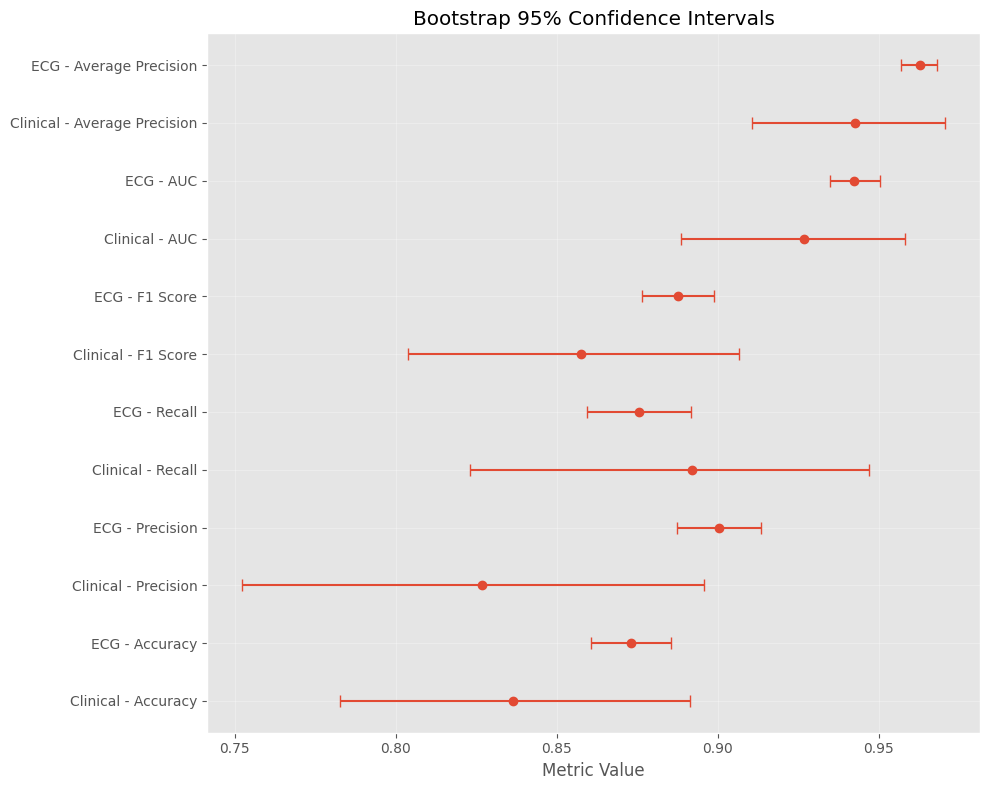

In [22]:
# ==========================================================
# Forest Plot
# ==========================================================

plot_df = bootstrap_df.copy()

plot_df["Label"] = (

    plot_df["Branch"]

    + " - "

    + plot_df["Metric"]

)

plt.figure(figsize=(10,8))

y_pos = np.arange(len(plot_df))

means = plot_df["Mean"]

lower = means - plot_df["95% CI Lower"]

upper = plot_df["95% CI Upper"] - means

plt.errorbar(

    means,

    y_pos,

    xerr=[lower,upper],

    fmt="o",

    capsize=4

)

plt.yticks(

    y_pos,

    plot_df["Label"]

)

plt.xlabel("Metric Value")

plt.title("Bootstrap 95% Confidence Intervals")

plt.grid(True,alpha=0.3)

plt.tight_layout()

plt.savefig(

    "11_bootstrap_confidence_intervals.png",

    dpi=300

)

plt.show()

In [23]:
# ==========================================================
# Save Bootstrap Results
# ==========================================================

bootstrap_df.to_csv(

    "11_bootstrap_confidence_intervals.csv",

    index=False

)

print("Bootstrap confidence intervals saved.")

Bootstrap confidence intervals saved.


# Section E — Comprehensive Branch Evaluation

This section performs a comprehensive evaluation of the finalized
Clinical (Random Forest) and ECG (CNN) branches.

Evaluation includes:

• ROC Curves
• Precision–Recall Curves
• Confusion Matrices
• Calibration Metrics
• Comparative Ablation Table
• Radar Chart Comparison

Only real evaluation metrics are reported.

No fusion accuracy is reported because no paired
clinical–ECG dataset exists.

In [24]:
# ==========================================================
# Final Metrics
# ==========================================================

clinical_metrics = {

    "Accuracy":
        accuracy_score(
            y_test_clinical,
            clinical_test_preds
        ),

    "Precision":
        precision_score(
            y_test_clinical,
            clinical_test_preds
        ),

    "Recall":
        recall_score(
            y_test_clinical,
            clinical_test_preds
        ),

    "F1 Score":
        f1_score(
            y_test_clinical,
            clinical_test_preds
        ),

    "AUC":
        roc_auc_score(
            y_test_clinical,
            clinical_test_probs
        ),

    "Average Precision":
        average_precision_score(
            y_test_clinical,
            clinical_test_probs
        ),

    "Brier":
        brier_score_loss(
            y_test_clinical,
            clinical_test_probs
        )

}

ecg_metrics = {

    "Accuracy":
        accuracy_score(
            y_test_ecg,
            ecg_test_preds
        ),

    "Precision":
        precision_score(
            y_test_ecg,
            ecg_test_preds
        ),

    "Recall":
        recall_score(
            y_test_ecg,
            ecg_test_preds
        ),

    "F1 Score":
        f1_score(
            y_test_ecg,
            ecg_test_preds
        ),

    "AUC":
        roc_auc_score(
            y_test_ecg,
            ecg_test_probs
        ),

    "Average Precision":
        average_precision_score(
            y_test_ecg,
            ecg_test_probs
        ),

    "Brier":
        brier_score_loss(
            y_test_ecg,
            ecg_test_probs
        )

}

print("Clinical Metrics")
display(pd.Series(clinical_metrics).round(4))

print()

print("ECG Metrics")
display(pd.Series(ecg_metrics).round(4))

# ==========================================================
# Expected Calibration Error (ECE) - additive metric
# ==========================================================

def expected_calibration_error(y_true, probs, n_bins=10):
    y_true = np.asarray(y_true)
    probs = np.asarray(probs)
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0
    for i in range(n_bins):
        mask = (probs >= bins[i]) & (probs < bins[i+1])
        if mask.sum() > 0:
            bin_acc = y_true[mask].mean()
            bin_conf = probs[mask].mean()
            ece += (mask.sum() / len(probs)) * abs(bin_acc - bin_conf)
    return ece

clinical_metrics["ECE"] = expected_calibration_error(
    np.asarray(y_test_clinical), clinical_test_probs
)
ecg_metrics["ECE"] = expected_calibration_error(
    np.asarray(y_test_ecg), ecg_test_probs
)

print("Clinical ECE:", round(clinical_metrics["ECE"], 4))
print("ECG ECE     :", round(ecg_metrics["ECE"], 4))


Clinical Metrics


Accuracy             0.8370
Precision            0.8273
Recall               0.8922
F1 Score             0.8585
AUC                  0.9262
Average Precision    0.9422
Brier                0.1130
dtype: float64


ECG Metrics


Accuracy             0.8728
Precision            0.9001
Recall               0.8757
F1 Score             0.8877
AUC                  0.9423
Average Precision    0.9626
Brier                0.0943
dtype: float64

Clinical ECE: 0.0653
ECG ECE     : 0.034


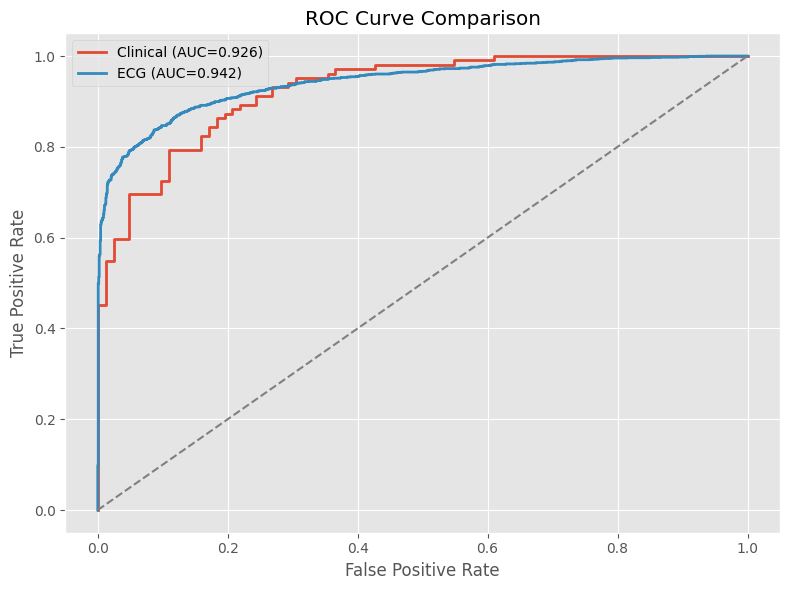

In [25]:
# ==========================================================
# ROC Curves
# ==========================================================

fpr_c,tpr_c,_ = roc_curve(
    y_test_clinical,
    clinical_test_probs
)

fpr_e,tpr_e,_ = roc_curve(
    y_test_ecg,
    ecg_test_probs
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr_c,
    tpr_c,
    linewidth=2,
    label=f"Clinical (AUC={clinical_metrics['AUC']:.3f})"
)

plt.plot(
    fpr_e,
    tpr_e,
    linewidth=2,
    label=f"ECG (AUC={ecg_metrics['AUC']:.3f})"
)

plt.plot(
    [0,1],
    [0,1],
    "--",
    color="gray"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.tight_layout()

plt.savefig(
    "11_roc_comparison.png",
    dpi=300
)

plt.show()

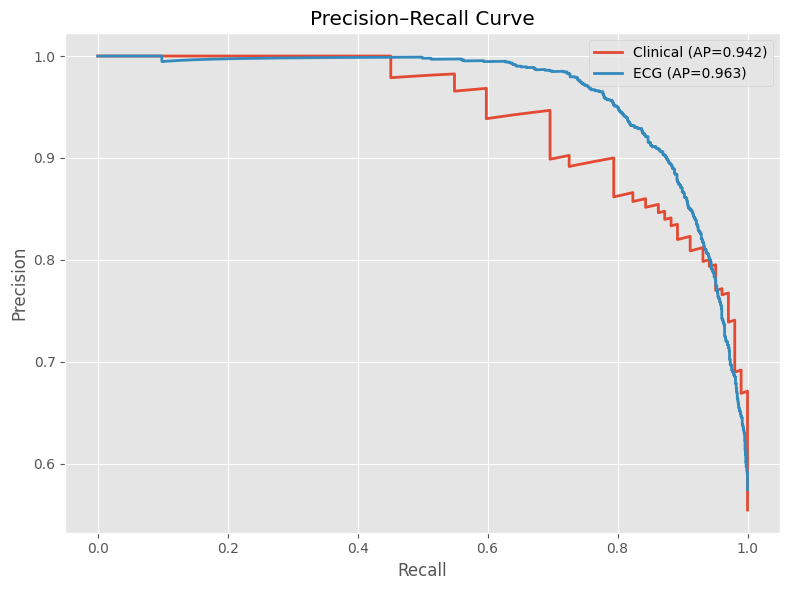

In [26]:
# ==========================================================
# Precision Recall Curves
# ==========================================================

pc,rc,_ = precision_recall_curve(
    y_test_clinical,
    clinical_test_probs
)

pe,re,_ = precision_recall_curve(
    y_test_ecg,
    ecg_test_probs
)

plt.figure(figsize=(8,6))

plt.plot(

    rc,

    pc,

    linewidth=2,

    label=f"Clinical (AP={clinical_metrics['Average Precision']:.3f})"

)

plt.plot(

    re,

    pe,

    linewidth=2,

    label=f"ECG (AP={ecg_metrics['Average Precision']:.3f})"

)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision–Recall Curve")

plt.legend()

plt.tight_layout()

plt.savefig(

    "11_pr_curve.png",

    dpi=300

)

plt.show()

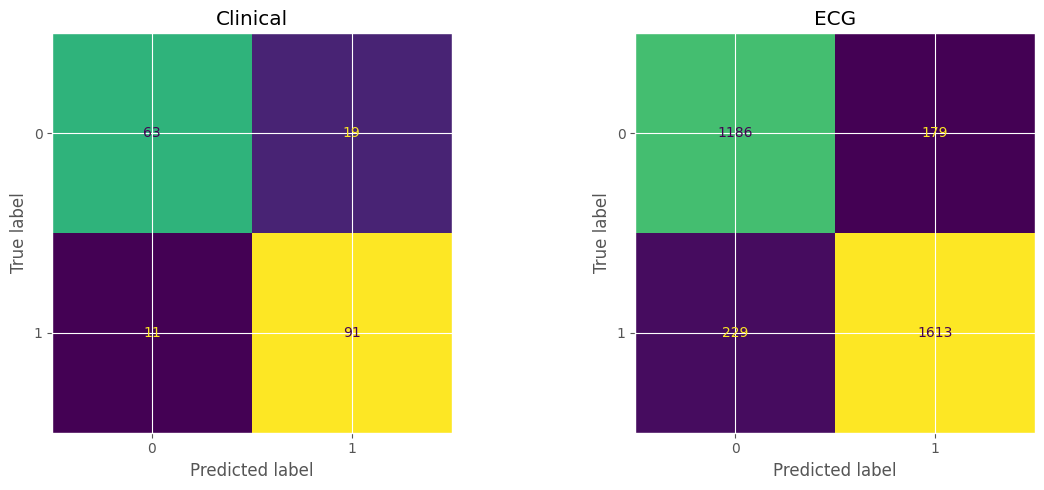

In [27]:
# ==========================================================
# Confusion Matrices
# ==========================================================

fig,ax = plt.subplots(
    1,
    2,
    figsize=(12,5)
)

ConfusionMatrixDisplay.from_predictions(

    y_test_clinical,

    clinical_test_preds,

    ax=ax[0],

    colorbar=False

)

ax[0].set_title("Clinical")

ConfusionMatrixDisplay.from_predictions(

    y_test_ecg,

    ecg_test_preds,

    ax=ax[1],

    colorbar=False

)

ax[1].set_title("ECG")

plt.tight_layout()

plt.savefig(

    "11_confusion_matrices.png",

    dpi=300

)

plt.show()

In [28]:
# ==========================================================
# Final Ablation Table
# ==========================================================

ablation = pd.DataFrame({

    "Metric":[

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score",

        "AUC",

        "Average Precision",

        "Brier",

        "ECE"

    ],

    "Clinical RF":[

        clinical_metrics["Accuracy"],

        clinical_metrics["Precision"],

        clinical_metrics["Recall"],

        clinical_metrics["F1 Score"],

        clinical_metrics["AUC"],

        clinical_metrics["Average Precision"],

        clinical_metrics["Brier"],

        clinical_metrics["ECE"]

    ],

    "ECG CNN":[

        ecg_metrics["Accuracy"],

        ecg_metrics["Precision"],

        ecg_metrics["Recall"],

        ecg_metrics["F1 Score"],

        ecg_metrics["AUC"],

        ecg_metrics["Average Precision"],

        ecg_metrics["Brier"],

        ecg_metrics["ECE"]

    ]

})

ablation = ablation.round(4)

display(ablation)

,Metric,Clinical RF,ECG CNN
0,Accuracy,0.8370,0.8728
1,Precision,0.8273,0.9001
2,Recall,0.8922,0.8757
3,F1 Score,0.8585,0.8877
4,AUC,0.9262,0.9423
5,Average Precision,0.9422,0.9626
6,Brier,0.1130,0.0943
7,ECE,0.0653,0.0340


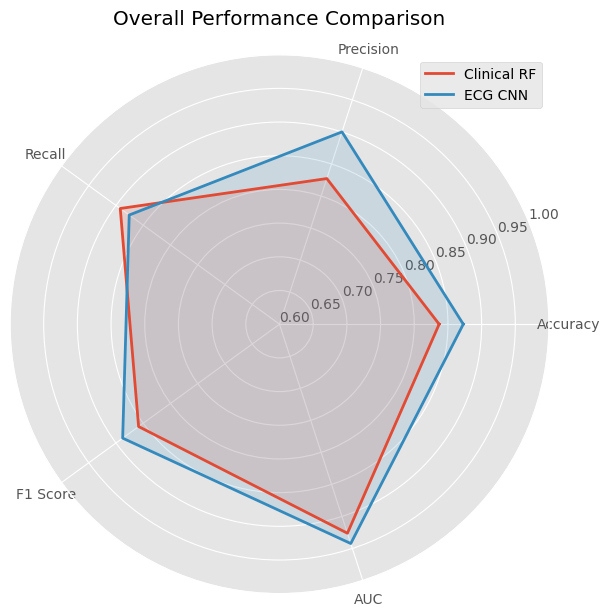

In [29]:
# ==========================================================
# Radar Chart
# ==========================================================

metrics = [

    "Accuracy",

    "Precision",

    "Recall",

    "F1 Score",

    "AUC"

]

angles = np.linspace(
    0,
    2*np.pi,
    len(metrics),
    endpoint=False
)

angles = np.concatenate(
    [angles,[angles[0]]]
)

clinical_values = [

    clinical_metrics[m]

    for m in metrics

]

clinical_values.append(clinical_values[0])

ecg_values = [

    ecg_metrics[m]

    for m in metrics

]

ecg_values.append(ecg_values[0])

fig = plt.figure(figsize=(7,7))

ax = plt.subplot(111,polar=True)

ax.plot(

    angles,

    clinical_values,

    linewidth=2,

    label="Clinical RF"

)

ax.fill(

    angles,

    clinical_values,

    alpha=0.15

)

ax.plot(

    angles,

    ecg_values,

    linewidth=2,

    label="ECG CNN"

)

ax.fill(

    angles,

    ecg_values,

    alpha=0.15

)

ax.set_xticks(angles[:-1])

ax.set_xticklabels(metrics)

ax.set_ylim(0.6,1.0)

plt.legend()

plt.title("Overall Performance Comparison\n")

plt.savefig(

    "11_radar_chart.png",

    dpi=300

)

plt.show()

In [30]:
# ==========================================================
# Save Evaluation
# ==========================================================

ablation.to_csv(

    "11_ablation_table.csv",

    index=False

)

pd.DataFrame({

    "Clinical":[clinical_metrics],

    "ECG":[ecg_metrics]

}).to_pickle(

    "11_metrics.pkl"

)

print("Evaluation artifacts saved.")

Evaluation artifacts saved.


# Section F.5 — Fusion Behavior Diagnostics

This section evaluates the **structural behavior** of the confidence-adaptive
fusion mechanism (built in Notebook 09), not a joint accuracy score.

As established in Notebook 09: UCI Heart Disease (clinical) and PTB-XL (ECG)
are separate, unrelated patient populations — there is no real paired ground
truth to compute a fusion accuracy against. These diagnostics characterize
how the mechanism behaves across the full space of possible confidence
inputs, which is the honest and defensible way to evaluate a decision-level
fusion module without paired patient data.


In [31]:
# ==========================================================
# Recreate Fusion Module Architecture (Mirroring Notebook 9)
# ==========================================================
import numpy as np

def confidence(probability):
    """
    Returns model confidence from a calibrated probability.
    Range:
        0.50 -> completely uncertain
        1.00 -> fully confident
    """
    probability = np.asarray(probability)
    return np.maximum(probability, 1 - probability)

def adaptive_fusion(clinical_prob, ecg_prob):
    clinical_conf = confidence(clinical_prob)
    ecg_conf = confidence(ecg_prob)

    weight_clinical = clinical_conf / (clinical_conf + ecg_conf)
    weight_ecg = ecg_conf / (clinical_conf + ecg_conf)

    fused_probability = (weight_clinical * clinical_prob) + (weight_ecg * ecg_prob)

    return {
        "clinical_probability": clinical_prob,
        "ecg_probability": ecg_prob,
        "clinical_confidence": clinical_conf,
        "ecg_confidence": ecg_conf,
        "clinical_weight": weight_clinical,
        "ecg_weight": weight_ecg,
        "fused_probability": fused_probability
    }

# If you also need the gamma-weighted version from Section 8:
def adaptive_fusion_gamma(clinical_prob, ecg_prob, gamma=3):
    clinical_conf = confidence(clinical_prob)
    ecg_conf = confidence(ecg_prob)

    clinical_weight = clinical_conf**gamma
    ecg_weight = ecg_conf**gamma

    clinical_weight = clinical_weight / (clinical_weight + ecg_weight)
    ecg_weight = 1 - clinical_weight

    fused_probability = (clinical_weight * clinical_prob) + (ecg_weight * ecg_prob)

    return {
        "clinical_weight": clinical_weight,
        "ecg_weight": ecg_weight,
        "fused_probability": fused_probability
    }

print("Fusion module loaded/recreated:", type(adaptive_fusion))

Fusion module loaded/recreated: <class 'function'>


In [32]:
# ==========================================================
# Fusion Output Surface (grid of confidence combinations)
# ==========================================================

clinical_grid = np.linspace(0.01, 0.99, 200)
ecg_grid = np.linspace(0.01, 0.99, 200)

fusion_outputs = np.zeros((200, 200))
for i, c in enumerate(clinical_grid):
    for j, e in enumerate(ecg_grid):
        result = adaptive_fusion(c, e)
        fusion_outputs[j, i] = (
            result["fused_probability"] if isinstance(result, dict) else result
        )

print("Fusion surface computed:", fusion_outputs.shape)


Fusion surface computed: (200, 200)


In [33]:
# ==========================================================
# Diagnostic 1: Agreement-Preserving Rate
# Diagnostic 2: Boundary-Uncertainty Rate (under disagreement)
# ==========================================================

clinical_decision = (clinical_grid >= 0.5).astype(int)
ecg_decision = (ecg_grid >= 0.5).astype(int)
fused_decision = (fusion_outputs >= 0.5).astype(int)

clinical_dec_grid = np.tile(clinical_decision, (200, 1))
ecg_dec_grid = np.tile(ecg_decision.reshape(-1, 1), (1, 200))

agreement_mask = clinical_dec_grid == ecg_dec_grid
agreement_rate = (
    fused_decision[agreement_mask] == clinical_dec_grid[agreement_mask]
).mean()

disagreement_mask = ~agreement_mask
boundary_mask = (fusion_outputs >= 0.45) & (fusion_outputs <= 0.55)
boundary_under_disagreement = boundary_mask[disagreement_mask].mean()

fusion_diagnostics = pd.DataFrame({
    "Diagnostic": [
        "Agreement-Preserving Rate",
        "Boundary-Uncertainty Rate (under disagreement)"
    ],
    "Value": [
        f"{agreement_rate*100:.1f}%",
        f"{boundary_under_disagreement*100:.1f}%"
    ],
    "Interpretation": [
        "When both branches agree, fusion preserves that agreed decision",
        "When branches strongly disagree, fusion lands near the decision "
        "boundary (appropriately uncertain) rather than confidently picking "
        "a side"
    ]
})

print(fusion_diagnostics.to_string(index=False))


                                    Diagnostic  Value                                                                                                                            Interpretation
                     Agreement-Preserving Rate 100.0%                                                                           When both branches agree, fusion preserves that agreed decision
Boundary-Uncertainty Rate (under disagreement)  28.7% When branches strongly disagree, fusion lands near the decision boundary (appropriately uncertain) rather than confidently picking a side


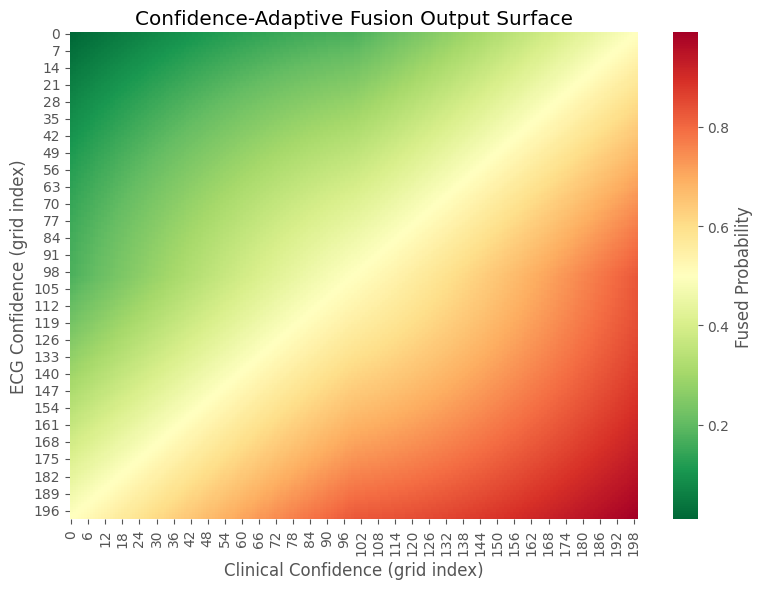

In [34]:
# ==========================================================
# Fusion Surface Heatmap
# ==========================================================

plt.figure(figsize=(8, 6))
sns.heatmap(fusion_outputs, cmap="RdYlGn_r", cbar_kws={"label": "Fused Probability"})
plt.xlabel("Clinical Confidence (grid index)")
plt.ylabel("ECG Confidence (grid index)")
plt.title("Confidence-Adaptive Fusion Output Surface")
plt.tight_layout()
plt.savefig("11_fusion_surface.png", dpi=300, bbox_inches="tight")
plt.show()


In [35]:
import os
import shutil
import zipfile

RESULTS_DIR = "results"

plots_dir = os.path.join(RESULTS_DIR, "plots")
tables_dir = os.path.join(RESULTS_DIR, "tables")
metrics_dir = os.path.join(RESULTS_DIR, "metrics")
models_dir = os.path.join(RESULTS_DIR, "models")

os.makedirs(plots_dir, exist_ok=True)
os.makedirs(tables_dir, exist_ok=True)
os.makedirs(metrics_dir, exist_ok=True)
os.makedirs(models_dir, exist_ok=True)

print("Directory structure created.")

Directory structure created.


In [36]:
plot_files = [

    # Bootstrap
    "11_bootstrap_confidence_intervals.png",

    # ROC / PR
    "11_roc_comparison.png",
    "11_pr_curve.png",

    # Confusion
    "11_confusion_matrices.png",

    # Radar
    "11_radar_chart.png",

    # Fusion Diagnostics
    "11_fusion_surface.png"

]

for f in plot_files:

    if os.path.exists(f):

        shutil.move(
            f,
            os.path.join(
                plots_dir,
                f
            )
        )

print("Plots organized.")

ablation.to_csv(

    os.path.join(
        tables_dir,
        "11_ablation_table.csv"
    ),

    index=False

)

bootstrap_df.to_csv(

    os.path.join(
        tables_dir,
        "11_bootstrap_confidence_intervals.csv"
    ),

    index=False

)

# Save fusion diagnostics table as well (additive)
if "fusion_diagnostics" in globals():
    fusion_diagnostics.to_csv(
        os.path.join(
            tables_dir,
            "11_fusion_diagnostics.csv"
        ),
        index=False
    )

print("Tables saved.")

Plots organized.
Tables saved.


In [37]:
metrics_summary = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "AUC",
        "Average Precision",
        "Brier",
        "ECE"
    ],

    "Clinical":[

        clinical_metrics["Accuracy"],
        clinical_metrics["Precision"],
        clinical_metrics["Recall"],
        clinical_metrics["F1 Score"],
        clinical_metrics["AUC"],
        clinical_metrics["Average Precision"],
        clinical_metrics["Brier"],
        clinical_metrics["ECE"]

    ],

    "ECG":[

        ecg_metrics["Accuracy"],
        ecg_metrics["Precision"],
        ecg_metrics["Recall"],
        ecg_metrics["F1 Score"],
        ecg_metrics["AUC"],
        ecg_metrics["Average Precision"],
        ecg_metrics["Brier"],
        ecg_metrics["ECE"]

    ]

})

metrics_summary.to_csv(

    os.path.join(
        metrics_dir,
        "11_final_metrics.csv"
    ),

    index=False

)

print(metrics_summary.round(4))

              Metric  Clinical     ECG
0           Accuracy    0.8370  0.8728
1          Precision    0.8273  0.9001
2             Recall    0.8922  0.8757
3           F1 Score    0.8585  0.8877
4                AUC    0.9262  0.9423
5  Average Precision    0.9422  0.9626
6              Brier    0.1130  0.0943
7                ECE    0.0653  0.0340


In [38]:
import pickle

with open(

    os.path.join(
        metrics_dir,
        "11_bootstrap_results.pkl"
    ),

    "wb"

) as f:

    pickle.dump(

        {

            "clinical":clinical_bootstrap,

            "ecg":ecg_bootstrap

        },

        f

    )

print("Bootstrap object saved.")

Bootstrap object saved.


In [39]:
summary = pd.DataFrame({

    "Property":[

        "Clinical Model",
        "ECG Model",

        "Clinical AUC",
        "ECG AUC",

        "Clinical Brier",
        "ECG Brier",

        "Clinical AP",
        "ECG AP",

        "Random Seed",

        "Bootstrap Samples"

    ],

    "Value":[

        "Random Forest",

        "1D CNN",

        round(clinical_metrics["AUC"],4),

        round(ecg_metrics["AUC"],4),

        round(clinical_metrics["Brier"],4),

        round(ecg_metrics["Brier"],4),

        round(clinical_metrics["Average Precision"],4),

        round(ecg_metrics["Average Precision"],4),

        SEED,

        1000

    ]

})

summary.to_csv(

    os.path.join(
        metrics_dir,
        "11_experiment_summary.csv"
    ),

    index=False

)

display(summary)

,Property,Value
0,Clinical Model,Random Forest
1,ECG Model,1D CNN
2,Clinical AUC,0.9262
3,ECG AUC,0.9423
4,Clinical Brier,0.113
5,ECG Brier,0.0943
6,Clinical AP,0.9422
7,ECG AP,0.9626
8,Random Seed,42
9,Bootstrap Samples,1000


In [40]:
zip_name = "Notebook11_Final_Evaluation.zip"

with zipfile.ZipFile(

    zip_name,

    "w",

    zipfile.ZIP_DEFLATED

) as zipf:

    for root,dirs,files in os.walk(RESULTS_DIR):

        for file in files:

            filepath = os.path.join(root,file)

            arcname = os.path.relpath(

                filepath,

                RESULTS_DIR

            )

            zipf.write(

                filepath,

                arcname

            )

print("ZIP Created Successfully")

ZIP Created Successfully


In [41]:
print(os.getcwd())
print()

print("Download this file from Output:")

print("Notebook11_Final_Evaluation.zip")

/kaggle/working

Download this file from Output:
Notebook11_Final_Evaluation.zip
